#  NeuroDock Analysis

## Consensus Docking Analysis for Alzheimer's Disease

### Author
Kirthi Maheswaran

### Objective
This notebook demonstrates how consensus docking scores can be used to rank potential Alzheimer's disease inhibitors using Python.

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv("../data/docking_scores.csv")

# Display the first few rows
df.head()



,Ligand,AutoDock_Vina,Glide,GOLD
0,Donepezil,-10.2,-9.8,-10.0
1,Galantamine,-9.5,-9.1,-9.3
2,Rivastigmine,-9.2,-8.9,-9.0
3,Tacrine,-9.0,-8.7,-8.8
4,Memantine,-7.2,-6.9,-7.1


## Calculate Consensus Scores

Consensus docking combines the results from multiple docking programs to provide a more reliable ranking of ligands.

In this notebook, the consensus score is calculated as the average of the AutoDock Vina, Glide, and GOLD docking scores.

In [14]:
# Calculate the consensus score
df["Consensus_Score"] = df[
    ["AutoDock_Vina", "Glide", "GOLD"]
].mean(axis=1)

# Rank ligands
ranked = df.sort_values("Consensus_Score")

# Display results
ranked

,Ligand,AutoDock_Vina,Glide,GOLD,Consensus_Score
0,Donepezil,-10.2,-9.8,-10.0,-10.000000
9,Huperzine A,-9.7,-9.4,-9.5,-9.533333
1,Galantamine,-9.5,-9.1,-9.3,-9.300000
2,Rivastigmine,-9.2,-8.9,-9.0,-9.033333
3,Tacrine,-9.0,-8.7,-8.8,-8.833333
7,Quercetin,-8.8,-8.4,-8.6,-8.600000
8,Berberine,-8.6,-8.3,-8.5,-8.466667
12,Kaempferol,-8.5,-8.2,-8.4,-8.366667
10,Luteolin,-8.4,-8.1,-8.3,-8.266667
11,Apigenin,-8.3,-8.0,-8.2,-8.166667


## Interpretation

A more negative consensus score suggests stronger predicted binding to the target protein.

The top-ranked ligand is considered the most promising candidate based on the consensus of all three docking programs.

## Consensus Score Visualization

The bar chart below shows the average (consensus) docking score for each ligand. More negative values indicate stronger predicted binding.

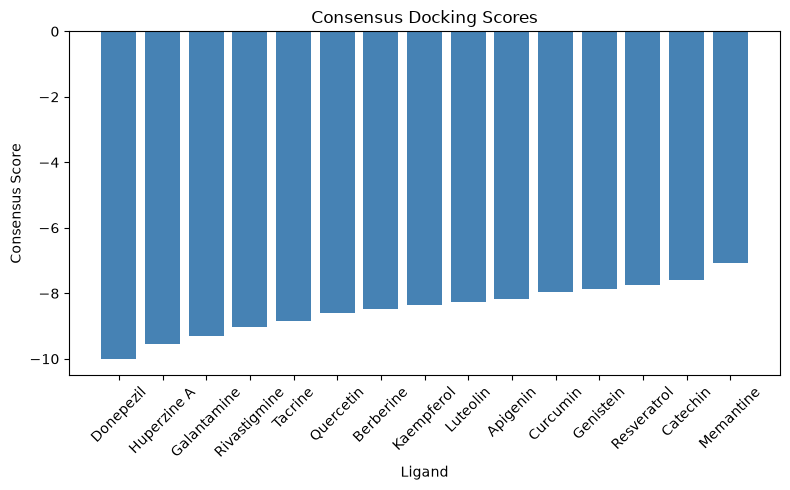

In [15]:
# Create a bar chart of consensus scores

plt.figure(figsize=(8,5))

plt.bar(
    ranked["Ligand"],
    ranked["Consensus_Score"],
    color="steelblue"
)

plt.title("Consensus Docking Scores")
plt.xlabel("Ligand")
plt.ylabel("Consensus Score")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

# Conclusion

The consensus docking analysis identified the ligands with the strongest predicted binding affinity by averaging docking scores from three docking programs.

Based on this dataset, **Donepezil** achieved the best consensus score, suggesting it is the most promising candidate among the compounds analysed.

This notebook demonstrates a simple computational workflow for analysing and visualising molecular docking results.

In [16]:
# Display the best ligand

best = ranked.iloc[0]

print("🏆 Best Ligand")
print(f"Name: {best['Ligand']}")
print(f"Consensus Score: {best['Consensus_Score']:.2f}")

🏆 Best Ligand
Name: Donepezil
Consensus Score: -10.00


# Summary Statistics

Before interpreting the docking results, it is useful to examine the overall distribution of the docking scores.

The summary statistics below provide information such as the average score, standard deviation, minimum, and maximum values for each docking program.

In [17]:
# Summary statistics
df.describe()

,AutoDock_Vina,Glide,GOLD,Consensus_Score
count,15.000000,15.000000,15.000000,15.000000
mean,-8.613333,-8.280000,-8.466667,-8.453333
std,0.800773,0.792104,0.766874,0.786170
min,-10.200000,-9.800000,-10.000000,-10.000000
25%,-9.100000,-8.800000,-8.900000,-8.933333
50%,-8.500000,-8.200000,-8.400000,-8.366667
75%,-8.050000,-7.750000,-7.950000,-7.916667
max,-7.200000,-6.900000,-7.100000,-7.066667


# Correlation Between Docking Programs

Different docking programs may produce similar or different scores.

A correlation matrix helps us determine whether the docking programs generally agree with one another.

In [18]:
# Correlation matrix
df[["AutoDock_Vina", "Glide", "GOLD"]].corr()

,AutoDock_Vina,Glide,GOLD
AutoDock_Vina,1.000000,0.998182,0.998764
Glide,0.998182,1.000000,0.998329
GOLD,0.998764,0.998329,1.000000


# Correlation Heatmap

The heatmap below visualizes the correlation between the three docking programs.

Correlation values close to **1** indicate strong agreement between the docking methods.

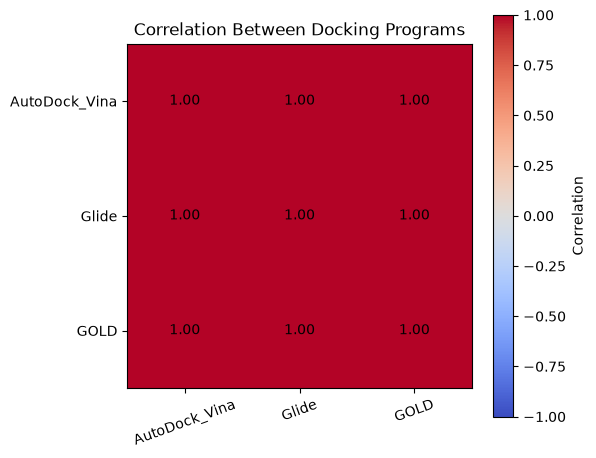

In [19]:
# Correlation heatmap

import matplotlib.pyplot as plt

corr = df[["AutoDock_Vina", "Glide", "GOLD"]].corr()

plt.figure(figsize=(6,5))

plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)

plt.colorbar(label="Correlation")

plt.xticks(range(3), corr.columns, rotation=20)
plt.yticks(range(3), corr.columns)

# Display correlation values
for i in range(len(corr)):
    for j in range(len(corr)):
        plt.text(j, i, f"{corr.iloc[i, j]:.2f}",
                 ha="center", va="center", color="black")

plt.title("Correlation Between Docking Programs")

plt.tight_layout()
plt.show()

# Distribution of Consensus Scores

The histogram below shows how the consensus docking scores are distributed across all ligands.

This helps identify whether most compounds have similar predicted binding affinities or whether there are clear outliers.

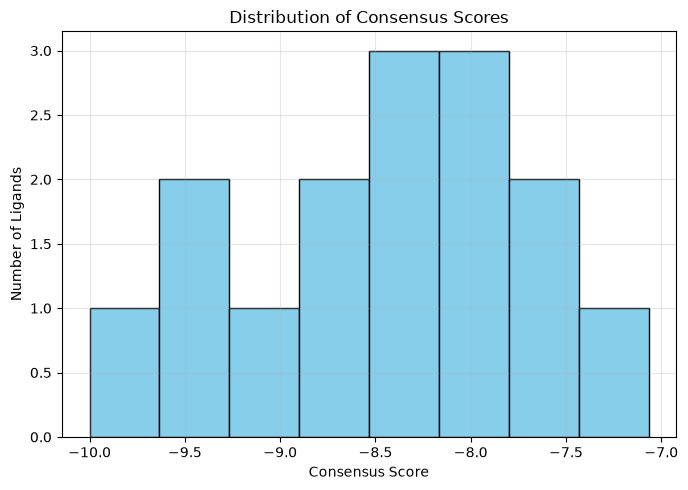

In [20]:
# Histogram of consensus scores

plt.figure(figsize=(7,5))

plt.hist(
    df["Consensus_Score"],
    bins=8,
    color="skyblue",
    edgecolor="black"
)

plt.title("Distribution of Consensus Scores")
plt.xlabel("Consensus Score")
plt.ylabel("Number of Ligands")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Overall Conclusion

This notebook demonstrates a simplified computational drug discovery workflow.

Using Python, consensus docking scores from three docking programs were analysed, ranked, and visualised.

The analysis identified the highest-ranked ligands and illustrated how data science tools such as Pandas and Matplotlib can support computational biology research.

Future improvements include analysing larger datasets, incorporating real docking outputs, and exploring additional statistical methods.

# Results

The consensus docking analysis ranked the ligands based on the average docking score obtained from AutoDock Vina, Glide, and GOLD.

Key observations:

- Donepezil achieved the most negative consensus score, indicating the strongest predicted binding affinity.
- The docking programs showed a high level of agreement, as demonstrated by the correlation analysis.
- Most ligands showed similar docking score ranges, while a few compounds stood out with stronger predicted binding.

In [21]:
# Display the top 5 ligands

ranked.head(5)

,Ligand,AutoDock_Vina,Glide,GOLD,Consensus_Score
0,Donepezil,-10.2,-9.8,-10.0,-10.000000
9,Huperzine A,-9.7,-9.4,-9.5,-9.533333
1,Galantamine,-9.5,-9.1,-9.3,-9.300000
2,Rivastigmine,-9.2,-8.9,-9.0,-9.033333
3,Tacrine,-9.0,-8.7,-8.8,-8.833333


# Discussion

Consensus docking combines predictions from multiple docking programs to improve confidence in ligand ranking.

In this project, averaging the docking scores reduced the influence of any single docking program and provided a simple method for identifying promising compounds for further study.

This workflow demonstrates how Python can be used to analyse and visualise docking results efficiently.